In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 3.8 MB/s eta 0:00:13
   - -------------------------------------- 1.8/48.9 MB 4.8 MB/s eta 0:00:10
   -- ------------------------------------- 3.4/48.9 MB 5.5 MB/s eta 0:00:09
   ---- ----------------------------------- 5.0/48.9 MB 6.0 MB/s eta 0:00:08
   ----- ---------------------------------- 7.3/48.9 MB 7.1 MB/s eta 0:00:06
   -------- ------------------------------- 10.0/48.9 MB 8.0 MB/s eta 0:00:05
   ----------- ---------------------------- 13.6/48.9 MB 9.3 MB/s eta 0:00:04
   -------------- ------------------------- 17.6/48.9 MB 10.5 MB/s eta 0:00:03
   ----------------- ---------------------- 21.0/48.9 MB 11.1 MB/s eta 0:00:03
   -------------------- ------------------- 25.2/48.9 MB 11.9 MB/s eta 0:00:03
   ------------------------- -------------- 30.7/48.9 MB 13.2 MB/s eta 0:00:02
   

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
# Generate synthetic insurance dataset

np.random.seed(42)

n = 500

age = np.random.randint(18, 70, n)
bmi = np.random.uniform(18, 40, n)
annual_income = np.random.randint(20000, 150000, n)
dependents = np.random.randint(0, 6, n)
previous_claims = np.random.randint(0, 5, n)
hospital_visits = np.random.randint(0, 10, n)
policy_duration = np.random.randint(1, 15, n)

# Create claim probability
risk_score = (
    0.03 * age
    + 0.08 * bmi
    + 0.30 * previous_claims
    + 0.15 * hospital_visits
    + 0.10 * dependents
    - 0.000002 * annual_income
)

probability = 1 / (1 + np.exp(-risk_score + 3.5))

claim = np.random.binomial(1, probability)

# Create DataFrame
data = pd.DataFrame({
    "Age": age,
    "BMI": bmi,
    "Annual_Income": annual_income,
    "Dependents": dependents,
    "Previous_Claims": previous_claims,
    "Hospital_Visits": hospital_visits,
    "Policy_Duration": policy_duration,
    "Claim": claim
})

data.head()

,Age,BMI,Annual_Income,Dependents,Previous_Claims,Hospital_Visits,Policy_Duration,Claim
0,56,39.007036,69688,0,3,6,10,0
1,69,34.233732,119929,0,0,7,9,1
2,46,30.195789,128618,3,2,2,6,0
3,32,31.457856,93509,3,4,4,5,1
4,60,27.231201,28577,2,4,0,3,1


In [4]:
print("Dataset Shape:", data.shape)

data.head(10)

Dataset Shape: (500, 8)


,Age,BMI,Annual_Income,Dependents,Previous_Claims,Hospital_Visits,Policy_Duration,Claim
0,56,39.007036,69688,0,3,6,10,0
1,69,34.233732,119929,0,0,7,9,1
2,46,30.195789,128618,3,2,2,6,0
3,32,31.457856,93509,3,4,4,5,1
4,60,27.231201,28577,2,4,0,3,1
5,25,23.450082,28070,1,3,6,9,0
6,38,25.831399,146161,4,4,4,5,1
7,56,34.672614,28666,4,0,7,5,1
8,36,18.316657,77761,4,0,7,14,0
9,40,20.553598,141178,2,3,8,4,1


In [5]:
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nStatistical Summary:")
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              500 non-null    int32  
 1   BMI              500 non-null    float64
 2   Annual_Income    500 non-null    int32  
 3   Dependents       500 non-null    int32  
 4   Previous_Claims  500 non-null    int32  
 5   Hospital_Visits  500 non-null    int32  
 6   Policy_Duration  500 non-null    int32  
 7   Claim            500 non-null    int32  
dtypes: float64(1), int32(7)
memory usage: 17.7 KB
None

Missing Values:
Age                0
BMI                0
Annual_Income      0
Dependents         0
Previous_Claims    0
Hospital_Visits    0
Policy_Duration    0
Claim              0
dtype: int64

Statistical Summary:
              Age         BMI  Annual_Income  Dependents  Previous_Claims  \
count  500.000000  500.000000     500.000000  500.000000       500.000000   
mean  

Claim Distribution:
Claim
1    386
0    114
Name: count, dtype: int64


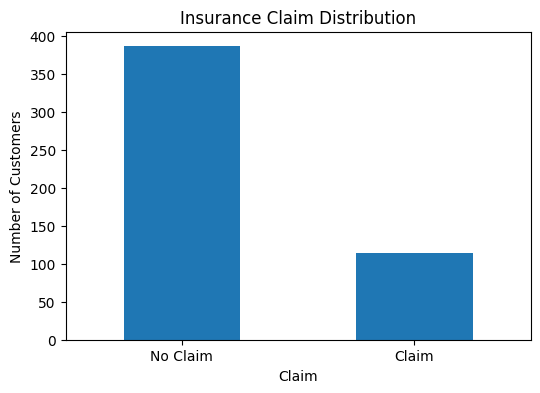

In [6]:
print("Claim Distribution:")
print(data["Claim"].value_counts())

data["Claim"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Insurance Claim Distribution")
plt.xlabel("Claim")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Claim", "Claim"], rotation=0)

plt.show()

In [7]:
X = data.drop("Claim", axis=1)

y = data["Claim"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age        BMI  Annual_Income  Dependents  Previous_Claims  \
0   56  39.007036          69688           0                3   
1   69  34.233732         119929           0                0   
2   46  30.195789         128618           3                2   
3   32  31.457856          93509           3                4   
4   60  27.231201          28577           2                4   

   Hospital_Visits  Policy_Duration  
0                6               10  
1                7                9  
2                2                6  
3                4                5  
4                0                3  

Target:
0    0
1    1
2    0
3    1
4    1
Name: Claim, dtype: int32


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 7)
Testing Data: (100, 7)


In [9]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [10]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.head(10).values)

print("\nPredicted Values:")
print(y_pred[:10])

Actual Values:
[1 1 1 0 0 1 1 1 1 1]

Predicted Values:
[1 1 1 1 1 1 1 1 1 1]


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Model Accuracy:",
      round(accuracy * 100, 2), "%")

XGBoost Model Accuracy: 77.0 %


In [12]:
print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Claim", "Claim"]
    )
)

Classification Report
              precision    recall  f1-score   support

    No Claim       0.50      0.13      0.21        23
       Claim       0.79      0.96      0.87        77

    accuracy                           0.77       100
   macro avg       0.64      0.55      0.54       100
weighted avg       0.72      0.77      0.71       100



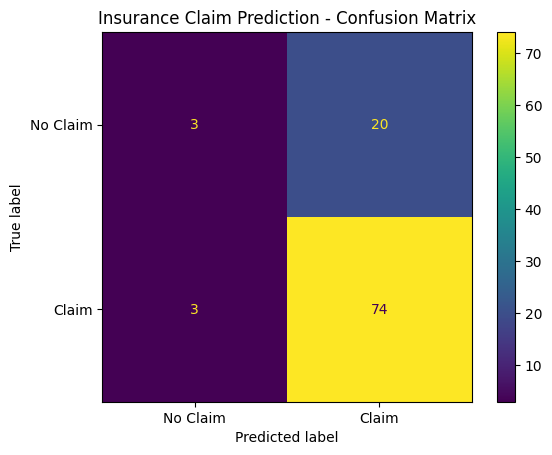

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Claim", "Claim"]
)

disp.plot()

plt.title("Insurance Claim Prediction - Confusion Matrix")

plt.show()

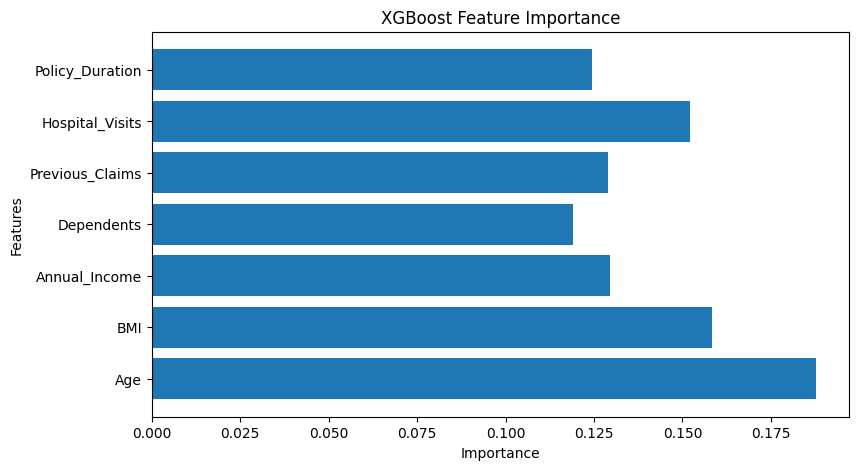

In [14]:
importance = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(9, 5))

plt.barh(feature_names, importance)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

plt.show()

In [15]:
new_customer = pd.DataFrame({
    "Age": [45],
    "BMI": [31.5],
    "Annual_Income": [50000],
    "Dependents": [3],
    "Previous_Claims": [2],
    "Hospital_Visits": [5],
    "Policy_Duration": [7]
})

prediction = model.predict(new_customer)
probability = model.predict_proba(new_customer)

print("Insurance Claim Prediction")
print("==========================")

if prediction[0] == 1:
    print("Prediction: CLAIM")
else:
    print("Prediction: NO CLAIM")

print(
    "No Claim Probability:",
    round(probability[0][0] * 100, 2),
    "%"
)

print(
    "Claim Probability:",
    round(probability[0][1] * 100, 2),
    "%"
)

Insurance Claim Prediction
Prediction: CLAIM
No Claim Probability: 9.99 %
Claim Probability: 90.01 %


In [16]:
customers = pd.DataFrame({
    "Age": [25, 35, 50, 60],
    "BMI": [22, 26, 34, 37],
    "Annual_Income": [80000, 60000, 45000, 30000],
    "Dependents": [0, 2, 3, 4],
    "Previous_Claims": [0, 1, 3, 4],
    "Hospital_Visits": [1, 2, 6, 8],
    "Policy_Duration": [5, 8, 10, 12]
})

predictions = model.predict(customers)

customers["Prediction"] = predictions

customers["Prediction"] = customers["Prediction"].map({
    0: "No Claim",
    1: "Claim"
})

customers

,Age,BMI,Annual_Income,Dependents,Previous_Claims,Hospital_Visits,Policy_Duration,Prediction
0,25,22,80000,0,0,1,5,No Claim
1,35,26,60000,2,1,2,8,Claim
2,50,34,45000,3,3,6,10,Claim
3,60,37,30000,4,4,8,12,Claim
